네트워크데이터분석_과제1_C321032_박하율

##### 1. Facebook Northwestern Univ. 네트워크 (N=10,567, L=488,337)를 기준으로 다음 물음에 답하시오.

In [1]:
N = 10567
L = 488337
#(a)
L_max = N*(N-1)/2
print("(a) 최대 링크 수 = ", L_max)

#(b)
density = L/L_max   #2L/N(N-1) undirected
print("(b) 네트워크 밀도 = ", round(density,6))

#(c)
#차수 = 링크 수 
k = (2*L)/N
print("(c) 평균 차수 <k> = ",round(k,2))

(a) 최대 링크 수 =  55825461.0
(b) 네트워크 밀도 =  0.008748
(c) 평균 차수 <k> =  92.43


##### 2. 다음 보기에서 옳은 설명을 모두 고르고, 틀린 설명은 이유를 한 문장으로 설명하시오.

(a) 방향성 네트워크에서 모든 노드의 in-degree 합과 out-degree 합은 항상 같다. TRUE<br> 

(b) 이분 네트워크(bipartite network)에서 같은 그룹 내 노드끼리는 직접 연결되지 않는다. TRUE<br>

(c) 완전 네트워크(complete network)의 밀도는 항상 d = 0.5이다. FALSE<br> 
    이유: 완전 네트워크는 모든 가능한 노드 쌍이 링크로 연결된 최대 링크 수를 가진 네트워크로 density = L/L_max = 1이다.<br>
    
(d) 희소 네트워크(sparse network)는 L << L_max 이고 d << 1 을 만족한다. TRUE

##### 3. 다음 질문에 대한 답을 작성하시오.

(a) 동류성(assortativity)과 비동류성(disassortativity)의 차이점과 실제 네트워크 예시를 각각 하나씩 드시오.<br>

- 차이점: 동류성은 높은 차수의 노드는 높은 차수의 노드와 낮은 차수의 노드는 낮은 차수의 노드와 연결되지만, 비동류성은 높은 차수의 노드가 낮은 차수의 노드와 연결된다.
- 동류성 네트워크: 소셜 네트워크 
- 비동류성 네트워크: 인터넷 네트워크 - 인터넷 망에서 허브 역할을 하는 라우터는 수많은 말단 노드들과 연결된다.

(b) 에코 챔버(echo chamber) 현상이 소셜 네트워크의 동류성과 어떻게 연결되는지 설명하시오.
- 에코 챔버: 같은 의견을 가진 사람에 둘러싸일 때 , 우리는 자신의 생각에 반하기보다는 더욱 강화하는 정보와 의견만을 접하게 되는 현상
- 소셜 네트워크에서 노드는 나이, 인종, 위치, 관심있는 주제 등의 여러 성질을 가지고 있고 연결된 노드는 비슷한 성질을 갖는 경향이 있다. 사람들은 자신과 비슷한 가치관, 취미 등을 가진 사람들과 어울리게 되고 자연스럽게 집단을 형성하게 되며 결과적으로는 자신의 생각을 강화하는 편향에 빠지게 된다.

(c) '여섯 단계 분리(six degrees of separation)'가 성립하는 이유를 평균 경로 길이와 네트워크 크기 N의 관계로 설명하시오.
- 네트워크에 수천만의 노드가 있더라도 평균 경로 길이는 여전히 한 자리 수이다. 예: 𝑙=𝑙𝑜𝑔𝑁
- 네트워크 크기가 크더라도 그만큼 한 노드에서 여러 단계를 거쳐 도달할 수 있는 노드 수도 기하급수적으로 증가하기때문에 모든 노드에 도달하기 위한 평균 경로 길이는 매우 천천히 증가한다. 따라서 평균 경로는 6단계 내외로 짧게 유지된다.

##### 4. 8개 노드(a~h)로 구성된 undirected network가 있다. 노드 연결: a-b, a-c, b-c, b-d, b-e, c-f, d-e, f-g, f-h

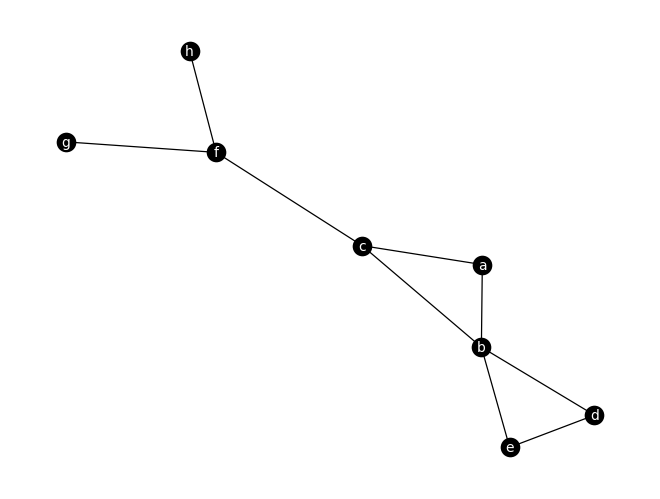

In [2]:
import networkx as nx 
import matplotlib.pyplot as plt 

G = nx.Graph()
G.add_edges_from([('a','b'),('a','c'),('b','c'),('b','d'),('b','e'),('c','f'),('d','e'),('f','g'),('f','h')])

options = {"node_color":"black", "node_size":200, "linewidths":0, "width":0.9}
pos = nx.spring_layout(G, seed=1969)
nx.draw(G, pos, **options)

nx.draw_networkx_labels(G, pos, font_size=10, font_color="white")
plt.show()


In [ ]:
#(a) 각 노드의 차수(degree)를 구하고 평균 차수를 계산하시오.
print("(a) 각 노드 차수: ",G.degree())
print("(a) 평균 차수: ", 2*G.size()/G.order())  #G.size=링크 수, G.order=노드 수

#(b) 노드 b의 뭉침 계수(clustering coefficient)를 직접 계산하시오. (공식과 풀이 과정 포함)
𝜏 = 2 ##노드b를 포함하는 삼각구조의 수 
k = 4 ##노드b의 이웃노드 수 

#뭉침계수 C = 2𝜏/𝑘(𝑘−1)
C_b = (2*𝜏)/(k*(k-1))
print("(b) b의 뭉침계수 = ",C_b)       

#(c) 노드 a와 g 사이의 최단 경로와 그 길이를 구하시오.
print("(c) 최단경로 : ", nx.shortest_path(G,source='a',target='g'))
print("(c) 최단경로 길이 : ", nx.shortest_path_length(G, source='a', target='g'))

(a) 각 노드 차수:  [('a', 2), ('b', 4), ('c', 3), ('d', 2), ('e', 2), ('f', 3), ('g', 1), ('h', 1)]
(a) 평균 차수:  2.25
(b) b의 뭉침계수 =  0.3333333333333333
(c) 최단경로 :  ['a', 'c', 'f', 'g']
(c) 최단경로 길이 :  3


##### 5. 너비 우선 탐색(BFS) 알고리즘에 대해 답하시오.

(a) BFS 알고리즘의 핵심 단계를 순서대로 기술하시오.

1. 원천 노드 s 를 frontier 에 넣고 노드 s 까지의 거리 ls,s =0 으로 설정한다. 다른 노드까지의 거리는 모두 -1 로 설정한다.
2. 노드 i를 방문하고 frontier 에서 제거한다. 노드 i의 후속 노드j 의 거리가 설정되지 않았다면 다음 단계를 따른다.<br>
    2-1.  노드 j 를 frontier 에 넣는다<br>
    2-2. 원천 노드에서 노드 j 까지의 거리를 l(s,j) =l(s,i) +1 로 설정한다<br>
    2-3. 노드 i에서 j로 링크를 최단 경로 트리에 추가한다<br>
3. frontier 가 비었다면 알고리즘 종료 . 그렇지 않으면 단계2 로 이동하여 반복한다.

(b) BFS와 최단 경로 트리(shortest-path tree)의 관계를 설명하시오.
- 원천 노드에서 시작하여 각 노도의 이웃 노드들을 layer로 계층화하고 트리를 구성한다. 이를 통해 루트와 다른 모든 노드 사이의 최단 경로를 찾을 수 있다.
- 모든 링크의 가중치가 1일 때, 너비 방향으로 탐색하며 먼저 발견되는 경로가 곧 최단 경로임을 보장한다.

(c) 오일러 경로(Eulerian Path)가 존재하기 위한 조건을 쾨니히스베르크 다리 문제와 연결하여 설명하시오.
- 쾨니히스베르크는 4개의 강이 7개의 다리로 연결되어 있다.(4개의 노드, 7개의 링크)
- 각 다리를 한 번씩만 지나면서 모든 다리를 지나는 경로가 존재하려면, 시작지점과 종료지점을 제외한 모든 지점이 짝수 개의 다리를 가져야 한다.
- 쾨니히스베르크의 4개 지점은 각각 차수가 3, 3, 3, 5로 모든 노드가 홀수 개의 링크를 가지므로 오일러 경로가 존재할 수 없다.

결론: 어떤 경로가 한 노드를 지나가려면 하나의 링크로 들어와서 하나의 링크로 나가야 하기 때문에 원천 노드와 목표 노드를 제외한 모든 노드가 짝수 개의 링크를 가져야만 오일러 경로가 존재할 수 있다.

##### 6. 아래 조건의 가중치 방향성 네트워크를 networkx로 생성하고 분석하시오.

노드: 0~6 (7개), 링크: (0→1, w=3), (0→3, w=2), (1→2, w=4), (2→5, w=1), (3→4, w=5), (4→2, w=2), (4→6, w=3), (5→6, w=4)

(a) 각 노드의 in-degree:  [(0, 0), (1, 1), (2, 2), (3, 1), (4, 1), (5, 1), (6, 2)]
(a) 각 노드의 out-degree:  [(0, 2), (1, 1), (2, 1), (3, 1), (4, 2), (5, 1), (6, 0)]
(a) 각 노드의 가중 degree:  [(0, 5), (1, 7), (2, 7), (3, 7), (4, 10), (5, 5), (6, 7)]

(b) 네트워크 밀도 =  0.190476

(c) 노드2의 predecessors:  [1, 4]
(c) 노드2의 successors:  [5]

(d)


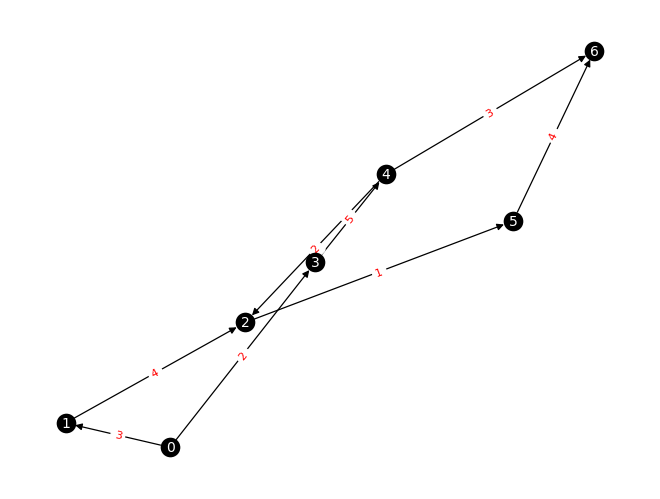

In [4]:
#directed & weighted
W = nx.DiGraph()
W.add_nodes_from([0,1,2,3,4,5,6])

W.add_weighted_edges_from([(0,1,3),(0,3,2),(1,2,4),(2,5,1),(3,4,5),(4,2,2),(4,6,3),(5,6,4)])

options = {"node_color":"black", "node_size":200, "linewidths":0, "width":0.9}
pos = nx.spring_layout(W, seed=1969)
nx.draw(W, pos, **options)

#(a) 각 노드의 in-degree, out-degree, 가중 degree
print("(a) 각 노드의 in-degree: ",W.in_degree())
print("(a) 각 노드의 out-degree: ",W.out_degree())
print("(a) 각 노드의 가중 degree: ",W.degree(weight="weight"))

#(b) 네트워크 밀도(density)
N = W.order()
L = W.size()
density = L/(N*(N-1))   #directed 네트워크
print("\n(b) 네트워크 밀도 = ", round(density,6))

#(c) 노드 2의 predecessors와 successors
print("\n(c) 노드2의 predecessors: ",list(W.predecessors(2)))
print("(c) 노드2의 successors: ",list(W.successors(2)))

#(d) nx.draw()로 네트워크 시각화 (엣지 가중치 표시)
nx.draw_networkx_labels(W, pos, font_size=10, font_color="white")

print("\n(d)")
edge_labels = {(u,v): d['weight'] for u, v, d in W.edges(data=True)}
nx.draw_networkx_edge_labels(W, pos, edge_labels=edge_labels, font_size=8, font_color="red")
plt.show()

##### 7. 문제 6에서 생성한 네트워크에 대해 다음을 수행하시오.

In [5]:
import warnings
warnings.filterwarnings('ignore')

#(a) 모든 노드 쌍에 대한 최단 경로 출력
print('(a)')
for i in dict(nx.shortest_path(W)):
    print(f'노드 {i}의 최단경로:' ,nx.shortest_path(W,i))
    
#(b) 강한 연결 구성요소(strongly connected components) 파악
print("\n(b) 강한 연결 구성요소: ",list(nx.strongly_connected_components(W)))

#(c) 약한 연결 구성요소(weakly connected components) 파악
print("\n(b) 약한 연결 구성요소: ",list(nx.weakly_connected_components(W)))

#(d) 가장 큰 구성요소(giant component)를 추출하고 연결성 확인
comps = sorted(nx.weakly_connected_components(W), key=len, reverse=True)
GC = comps[0]
print("\n(d) 가장 큰 구성요소: ",GC)

#(e) 방향성을 무시했을 때 평균 경로 길이 계산
G = W.to_undirected()
print("\n(e) 평균 경로 길이: ",round(nx.average_shortest_path_length(G),3))

(a)
노드 0의 최단경로: {0: [0], 1: [0, 1], 3: [0, 3], 2: [0, 1, 2], 4: [0, 3, 4], 5: [0, 1, 2, 5], 6: [0, 3, 4, 6]}
노드 1의 최단경로: {1: [1], 2: [1, 2], 5: [1, 2, 5], 6: [1, 2, 5, 6]}
노드 2의 최단경로: {2: [2], 5: [2, 5], 6: [2, 5, 6]}
노드 3의 최단경로: {3: [3], 4: [3, 4], 2: [3, 4, 2], 6: [3, 4, 6], 5: [3, 4, 2, 5]}
노드 4의 최단경로: {4: [4], 2: [4, 2], 6: [4, 6], 5: [4, 2, 5]}
노드 5의 최단경로: {5: [5], 6: [5, 6]}
노드 6의 최단경로: {6: [6]}

(b) 강한 연결 구성요소:  [{6}, {5}, {2}, {1}, {4}, {3}, {0}]

(b) 약한 연결 구성요소:  [{0, 1, 2, 3, 4, 5, 6}]

(d) 가장 큰 구성요소:  {0, 1, 2, 3, 4, 5, 6}

(e) 평균 경로 길이:  1.81


##### 8. Zachary's Karate Club 네트워크를 불러와 동류성을 분석하시오.

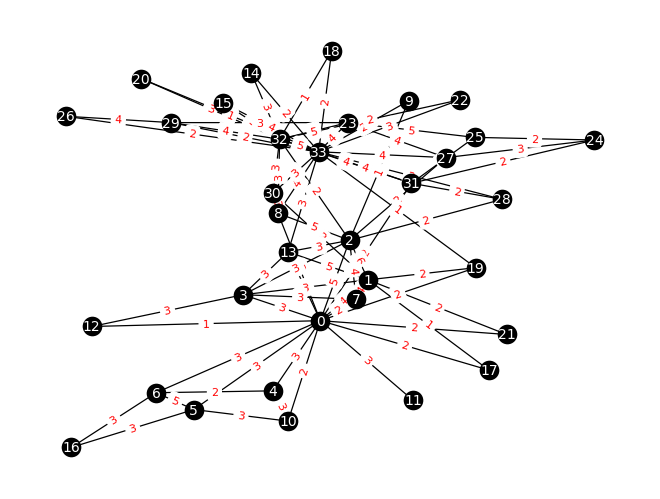

In [6]:
import networkx as nx
G = nx.karate_club_graph()

options = {"node_color":"black", "node_size":200, "linewidths":0, "width":0.9}
pos = nx.spring_layout(G, seed=1969)
nx.draw(G, pos, **options)

nx.draw_networkx_labels(G, pos, font_size=10, font_color="white")

edge_labels = {(u,v): d['weight'] for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, font_color="red")
plt.show()

(a) -0.47561309768461413
(a) r이 음수이므로 disassortative

(b)
Disassortative Network - Degree Assortativity Coefficient: -0.476


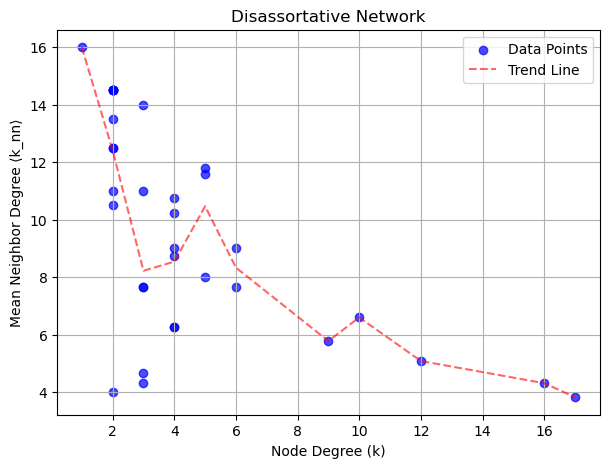


Disassortative Network - Node Degree vs. Mean Neighbor Degree
Degree 16: Mean Neighbor Degree 4.31
Degree 9: Mean Neighbor Degree 5.78
Degree 10: Mean Neighbor Degree 6.60
Degree 6: Mean Neighbor Degree 7.67
Degree 3: Mean Neighbor Degree 7.67
Degree 4: Mean Neighbor Degree 6.25
Degree 4: Mean Neighbor Degree 6.25
Degree 4: Mean Neighbor Degree 10.25
Degree 5: Mean Neighbor Degree 11.80
Degree 2: Mean Neighbor Degree 13.50
Degree 3: Mean Neighbor Degree 7.67
Degree 1: Mean Neighbor Degree 16.00
Degree 2: Mean Neighbor Degree 11.00
Degree 5: Mean Neighbor Degree 11.60
Degree 2: Mean Neighbor Degree 14.50
Degree 2: Mean Neighbor Degree 14.50
Degree 2: Mean Neighbor Degree 4.00
Degree 2: Mean Neighbor Degree 12.50
Degree 2: Mean Neighbor Degree 14.50
Degree 3: Mean Neighbor Degree 14.00
Degree 2: Mean Neighbor Degree 14.50
Degree 2: Mean Neighbor Degree 12.50
Degree 2: Mean Neighbor Degree 14.50
Degree 5: Mean Neighbor Degree 8.00
Degree 3: Mean Neighbor Degree 4.33
Degree 3: Mean Neighb

In [ ]:
#(a) degree assortativity coefficient 계산 및 해석 (assortative인지 disassortative인지 판단하고 이유 설명)
print("(a)", nx.degree_assortativity_coefficient(G))
print("(a) r이 음수이므로 disassortative")

#(b) 각 노드의 k_nn(i) (이웃 노드들의 평균 차수) 계산
def analyze_knn(G, title):
    """ 네트워크의 KNN 값을 계산하고 시각화하는 함수 """
    # Degree Assortativity 계수 출력
    assortativity_coefficient = nx.degree_assortativity_coefficient(G)
    print(f"{title} - Degree Assortativity Coefficient: {assortativity_coefficient:.3f}")

    # KNN 값 계산
    mean_neighbor_degrees = nx.average_neighbor_degree(G)

    # Degree vs. Mean Neighbor Degree 데이터 준비
    degree_dict = dict(G.degree())  # 각 노드의 차수
    degrees = list(degree_dict.values())  # 차수 값 리스트
    mean_degrees = list(mean_neighbor_degrees.values())  # 평균 이웃 차수 리스트
    
    #차수 k별 평균 이웃 차수 k_nn(k) 계산
    knn_k = nx.average_degree_connectivity(G) 
    sorted_k = sorted(knn_k.keys())
    sorted_knn = [knn_k[k] for k in sorted_k]

    # 시각화
    plt.figure(figsize=(7, 5))
    plt.scatter(degrees, mean_degrees, color='b', alpha=0.7, label="Data Points")
    plt.plot(sorted_k, sorted_knn, linestyle='--', color='r', alpha=0.6, label="Trend Line") 
    plt.xlabel("Node Degree (k)")
    plt.ylabel("Mean Neighbor Degree ⟨k_nn⟩")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

    # KNN 결과 출력
    print(f"\n{title} - Node Degree vs. Mean Neighbor Degree")
    for deg, knn in zip(degrees, mean_degrees):
        print(f"Degree {deg}: Mean Neighbor Degree {knn:.2f}")

print("\n(b)")
analyze_knn(G, "Disassortative Network")

#####(c) 차수 k에 따른 k_nn(k) 값을 계산하여 k가 증가함에 따라 k_nn(k)가 증가하는지 감소하는지 확인
#k_nn이 감소함수이므로 높은 차수 노드가 낮은 차수의 노드와 연결된다 = disassortative

##### (d) (b)와 (c) 결과가 (a)의 결과와 일치하는지 비교·설명
#(a)에서 Assortativity coefficient 계산 결과 -0.4756으로, disassortative로 판단하였다.
#(b),(c)에서 각 노드의 이웃 노드의 평균 차수를 계산하고 k_nn(k) 함수의 추세를 본 결과, 감소 추세를 보여 disassortative로 판단하였다.
#따라서, 이 네트워크는 비동류성을 갖는 네트워크이다.

##### 9. 아래 세 네트워크를 생성하고 '좁은 세상' 특성을 비교 분석하시오.

각 네트워크에 대해 출력: (a) 노드 수, 링크 수, 밀도 (b) 평균 경로 길이 <l> (c) 평균 뭉침 계수 C (d) log(N) 값과 <l> 비교<br>
※ 결과를 표로 정리하고, 어느 네트워크가 가장 '좁은 세상'에 가까운지 판단하는 2~3문장의 해석을 작성하시오.

In [ ]:
G1 = nx.karate_club_graph() # 소셜 네트워크
G2 = nx.grid_2d_graph(10, 10) # 격자 네트워크
G3 = nx.barabasi_albert_graph(100, 3) # 척도 없는 네트워크

#(a) 노드 수, 링크 수, 밀도
print("(a) 노드 수: ",G1.order(),G2.order(),G3.order())
print("(a) 링크 수: ",G1.size(),G2.size(),G3.size())
d1 = (2*G1.size())/(G1.order()*(G1.order()-1))
d2 = (2*G2.size())/(G2.order()*(G2.order()-1))
d3 = (2*G3.size())/(G3.order()*(G3.order()-1))
print("(a) 밀도: ",round(d1,3),round(d2,3),round(d3,3))

#(b) 평균경로길이
print("\n(b) 평균 경로 길이: ",round(nx.average_shortest_path_length(G1),3),round(nx.average_shortest_path_length(G2),3),round(nx.average_shortest_path_length(G3),3))

#(c) 평균 뭉침 계수 C
C1 = nx.average_clustering(G1)
C2 = nx.average_clustering(G2)
C3 = nx.average_clustering(G3)
print("\n(c) 평균 뭉침 계수: ",round(C1,3),round(C2,3),round(C3,3))

#(d) log(N)
import math
print("\n(d) log(N): ", round(math.log10(G1.order()),3), round(math.log10(G2.order()),3), round(math.log10(G3.order()),3))

(a) 노드 수:  34 100 100
(a) 링크 수:  78 180 291
(a) 밀도:  0.139 0.036 0.059

(b) 평균 경로 길이:  2.408 6.667 2.601

(c) 평균 뭉침 계수:  0.571 0.0 0.171

(d) log(N):  1.531 2.0 2.0


| 네트워크 | 노드 수 | 링크 수 | 밀도 | 평균 경로 길이 | 평균 뭉침 계수 | log(N) |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| G1 | 34 | 78 | 0.139 | 2.408 | 0.571 | 1.531 |
| G2 | 100 |180 | 0.036 | 6.667 | 0.0 | 2.0 |
| G3 | 100 | 291 | 0.059 | 2.601 | 0.171 | 2.0 |

좁은 세상은 짧은 평균 경로길이와 함께 높은 뭉침계수가 특징이다. G1 네트워크는 평균 경로 길이가 2.408로 짧아 노드 간 간격이 작음을 알 수 있다. 또한, 평균 뭉침계수가 0.571로 다른 네트워크에 비해 크므로 해당 네트워크에 삼각 구조가 많음을 의미한다. 즉, 노드들이 서로 연결되어 촘촘한 그룹을 형성하는 것이다. 

따라서 G1이 가장 좁은 세상에 가까운 네트워크이다.


##### 10. 아래 두 사이트 중 하나에서 관심 있는 네트워크 데이터 1개를 직접 다운로드하여 분석하시오.
- https://snap.stanford.edu/data/ 
- https://networkrepository.com/

(a) 선택한 데이터셋의 이름, 출처 URL, 네트워크 종류(directed/undirected, weighted/unweighted)를 기재하시오.<br>
(b) 노드 수, 링크 수, 밀도, 평균 차수, 평균 경로 길이(giant component 기준), 뭉침 계수를 계산하여 표로 제시하시오.<br>
(c) degree assortativity coefficient를 계산하고 네트워크의 동류성을 해석하시오.<br>
(d) 다음 표의 네트워크와 비교하여 분석 결과를 3~5문장으로 논의하시오.

In [33]:
#(a) Astro Physics collaboration network, https://snap.stanford.edu/data/ca-AstroPh.html, undirected & unweighted
import networkx as nx

# 파일 경로 설정 (파일명: CA-AstroPh.txt)
file_path = 'CA-AstroPh.txt'

G = nx.read_edgelist(file_path, 
                    comments='#',        # '#'으로 시작하는 주석 줄 무시
                    create_using=nx.Graph(), 
                    nodetype=int)        # 노드 ID를 정수형으로 변환

#(b)
N = G.order()
L = G.size()
density = (2*L)/(N*(N-1))
print("(b) 노드 수, 링크 수, 밀도: ",N,L,round(density,3))
print("(b) 평균 차수: ", round((2*L)/N,3))

#giant component 기준
components = sorted(nx.connected_components(G), key=len, reverse=True)
G_giant = G.subgraph(components[0])

import random

# Giant Component에서 500개의 노드만 샘플링하여 근사치 계산
sample_nodes = random.sample(list(G_giant.nodes()), 500)
distances = []

for source in sample_nodes:
    # 한 노드에서 다른 모든 노드까지의 최단 경로 길이를 구함
    path_lengths = nx.single_source_shortest_path_length(G_giant, source)
    distances.extend(path_lengths.values())

avg_path_approx = sum(distances) / len(distances)
print(f"(b) 평균 경로 길이: {avg_path_approx:.3f}")

print("(b) 평균 뭉침 계수: ", round(nx.average_clustering(G),3))

print("\n(c) degree assortativity coefficient: ", round(nx.degree_assortativity_coefficient(G),4))


(b) 노드 수, 링크 수, 밀도:  18772 198110 0.001
(b) 평균 차수:  21.107
(b) 평균 경로 길이: 4.214
(b) 평균 뭉침 계수:  0.631

(c) degree assortativity coefficient:  0.2051


| 노드 수 | 링크 수| 밀도 | 평균 차수 | 평균 경로 길이 | 뭉침 계수 |
| :---: | :---: | :---: | :---: | :---: | :---: |
| 18772 | 198110 | 0.001 | 21.107 | 4.214 | 0.631 | 

- 네트워크의 동류성: degree assortativity coefficient = 0.2051로 양의 상관계수를 가지므로 동류성 네트워크이다. 
- 네트워크 비교분석: 이 네트워크는 노드 수가 18772개로 Wikipedia math나 Twitter US politics와 유사한 규모를 갖는다. 이 두 네트워크와 비교했을 때 평균 차수가 21.1로 훨씬 커 노드 간 연결이 보다 활발한 네트워크임을 알 수 있다. 차수는 높지만 밀도는 0.001로 매우 낮아 희소 네트워크의 특징을 갖는다. 동시에 평균 경로 길이는 4.214로 매우 짧아 좁은 세상 네트워크이다. 또한 뭉침 계수가 0.631로 해당 네트워크에 삼각 구조가 많고, 노드들이 서로 연결되어 촘촘한 그룹을 이루고 있음을 알 수 있다. 이는 공동 저자 관계라는 특성상 지인들끼리 서로 협력하는 강한 군집 구조를 형성하기 때문이다. 마지막으로 동류성 계수가 0.2051인 양의 상관관계를 보이므로, 이는 유사한 노드들끼리 연결되는 동류성 네트워크이다.